In [1]:
import numpy as np, random
from scipy.linalg import norm
from tqdm import tqdm

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
def refine_grid_2d(HII_DIM, refine_cells, levels):
    """
    Generate a 2D grid with refinement at specified cells.
    
    If a cell is refined, it is replaced by its refined sub-cells.

    Parameters:
        HII_DIM (int): Coarse grid size.
        refine_cells (list): List of (i, j) cells to refine.
        levels (dict): Mapping (i, j) -> refinement level.

    Returns:
        x_grid (np.array): x-coordinates of final cells (lower-left corner).
        y_grid (np.array): y-coordinates of final cells.
        dr (np.array): size of each final cell.
    """
    x_grid = []
    y_grid = []
    dr = []
    
    for i in range(HII_DIM):
        for j in range(HII_DIM):
            if (i, j) in refine_cells:
                level = levels[(i, j)]
                sub_divs = 2**level
                dx = 1.0 / sub_divs
                
                # Refine cell into sub_divs × sub_divs sub-cells
                x_sub_cells = np.linspace(i, i + 1, 2**(level+1) + 1)[1:-1]
                y_sub_cells = np.linspace(j, j + 1, 2**(level+1) + 1)[1:-1]

                for x in x_sub_cells:
                    for y in y_sub_cells:
                        if(x % dx != 0 and y % dx != 0):
                            x_grid.append(x)
                            y_grid.append(y)
                            dr.append(dx)
            else:
                # Only keep coarse cell if it was NOT refined
                x_grid.append(i+0.5)
                y_grid.append(j+0.5)
                dr.append(1.0)
    
    return np.array(x_grid), np.array(y_grid), np.array(dr)


def plot_irregular_grid_cells(r_c, dr, color='white', ax=None):
    for i_c in range(r_c.shape[0]):
        rect = patches.Rectangle((r_c[i_c,0]-dr[i_c]/2, r_c[i_c,1]-dr[i_c]/2), 
                                  dr[i_c], dr[i_c], 
                                  linewidth=0.8,
                                  edgecolor='black',
                                  facecolor=color,
                                  alpha=1.0)
        ax.add_patch(rect)

def plot_ray(r_s, r_t):
    n_st = (r_t - r_s) / norm(r_t - r_s)
    
    t = np.linspace(0., norm(r_t - r_s), 100)
    r_x, r_y = np.zeros_like(t), np.zeros_like(t)
    
    for i_d, d in enumerate(t):
        r_x[i_d] = r_s[0] + d*n_st[0]
        r_y[i_d] = r_s[1] + d*n_st[1]
        
    return r_x, r_y

## Define irregular grid

In [38]:
# box mesh and cell size
HII_DIM = 28 
dL = 0.6
boxsize = HII_DIM * dL

sigma_HI_at_ion_freq = 6.30e-18 # in cgs

In [39]:
# define position of the refinde cells
#refine_cells = [(3, 3), (3, 4), (4, 3), (4, 4), (5, 3), (5, 4), (3, 5), (4, 5), (5, 5)]
refine_cells = []

# define level of the refined cells (resolution: 2^levels, similar to Ramses-RT)
#levels = {(3, 3): 2, (3, 4): 1, (4, 3): 1, (4, 4): 1, (5, 3): 1, (5, 4): 1, (3, 5): 1, (4, 5): 1, (5, 5): 1}
levels = {}

# Create refined 2D grid (no specific convention)
x_grid, y_grid, dr = refine_grid_2d(HII_DIM=HII_DIM, refine_cells=refine_cells, levels=levels)

# Coordinate of each cells (at the center of the cell)
r_grid = np.vstack((x_grid, y_grid)).T

## Define source & target position

In [40]:
#r_target = np.array([5.25, 4.25])
#r_target = np.array([5.25, 4.75])
r_target = np.array([5.5, 4.5])+20
#r_target = np.array([5.5, 1.5])
r_source = np.array([1.5, 1.5])

## Call the raytracing algorithm

In [41]:
# density grid
ndens = np.ones((HII_DIM, HII_DIM)) * 1e-3

# only rays in the direction of the the target (manual: in reality it is until box, here is just to have a just one ray)
mask_x = (r_grid[:, 0] <= np.ceil(r_target[0])) * (r_grid[:, 0] >= r_source[0])
mask_y = (r_grid[mask_x, 1] <= np.ceil(r_target[1])) * (r_grid[mask_x, 1] >= r_source[1])

# cells position
r_cell = r_grid[mask_x][mask_y]
dr_grid = dr[mask_x][mask_y]

# this only for the regular grid test
dr_cell = dr[0]#/2

# source to cells vector
r_sc = r_cell - r_source

# vector from source to target
r_st = r_target-r_source
n_st = r_st/np.linalg.norm(r_st)

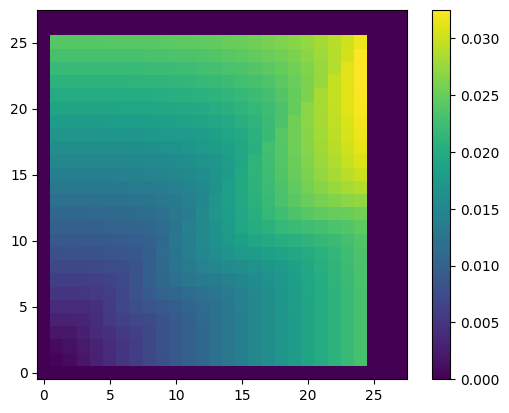

In [42]:
ncols = np.zeros((HII_DIM, HII_DIM))

# loop over the cells in the direction of the target (this is only to compare with long-charaterisitcs)
for r_c in r_cell:
    i, j = (r_c - 0.5).astype(int)
    
    # half the cell size
    path = 0.5*dr_cell
    
    # distance between the cell (center) and the source (center)
    delt_i = r_c[0] - r_source[0]
    delt_j = r_c[1] - r_source[1]
    
    # orientation of r_sc vector
    sign_i = np.sign(delt_i)
    sign_j = np.sign(delt_j)

    if (delt_i == 0) and (delt_j == 0):
        # Origin cell
        ncols_in = 0.0
        ncols[i, j] = ncols_in + path*ndens[i,j]
    elif (delt_i == 0 and delt_j != 0): 
        # Ray propagating along y-axis
        
        # previous column density calculation (up to the cell's center)
        ncols_in = ncols[i,j-1]
        
        if (delt_j > 1):
            # add the missing half step (after the cell's center)
            ncols_in += path*ndens[i,j-1]
        
        ncols[i,j] = ncols_in + path*ndens[i,j]
    elif (delt_j == 0 and delt_i != 0): 
        # Ray propagating along x-axis
        
        # previous column density calculation (up to the cell's center)
        ncols_in = ncols[i-1,j]
        
        if (delt_i > 1):
            # add the missing half step (after the cell's center)
            ncols_in += path*ndens[i-1,j]
        
        ncols[i,j] = ncols_in + path*ndens[i,j]
    elif (delt_i == delt_j and delt_i != 0 and delt_j != 0):
        # Ray propagating along diagonal of the cell
        
        # previous column density calculation (up to the cell's center)        
        ncols_in = ncols[i-1,j-1]
        
        # previous column density calculation (up to the cell's center)
        if (delt_i == 1 and delt_j == 1):
            ncols_in *= np.sqrt(2)
        elif (delt_i > 1):
            # add the missing half step (after the cell's center)
            ncols_in += path*np.sqrt(2)*ndens[i-1,j-1]
            
        ncols[i,j] = ncols_in + path*np.sqrt(2)*ndens[i,j]
        
#plt.imshow(ncols, vmin=0, origin='lower')
#plt.colorbar()
#plt.show()

# same as before but need to be separated (cross direction first)
for r_c in r_cell:
    i, j = (r_c - 0.5).astype(int)
    
    # half the cell size
    path = 0.5*dr_cell
    
    # distance between the cell (center) and the source (center)
    delt_i = r_c[0] - r_source[0]
    delt_j = r_c[1] - r_source[1]
    
    # orientation of r_sc vector
    sign_i = np.sign(delt_i)
    sign_j = np.sign(delt_j)
    
    if (delt_i == 0) and (delt_j == 0):
        pass
    elif (delt_i == 0): 
        pass
    elif (delt_j == 0): 
        pass
    elif(np.abs(delt_i) > np.abs(delt_j)):
        ds = np.sqrt(1 + delt_j**2/delt_i**2)

        xc = r_c[0] - sign_i*path
        yc = delt_j/delt_i * (delt_i - sign_i*path) + r_source[1]

        #dy = 2*np.abs(yc - (r_c[1] - sign_j*0.5))
        dy = 2*np.abs(xc - (i - sign_i*0.5))
        w1, w2 = (1.-dy)/np.max([0.6,ncols[i-1,j]*sigma_HI_at_ion_freq]), dy/np.max([0.6,ncols[i-1,j-1]*sigma_HI_at_ion_freq])
        
        ncols_in = (w1*ncols[i-1,j] + w2*ncols[i-1,j-1])/(w1+w2)
        ncols[i,j] = ncols_in + ds*ndens[i,j]

    elif(np.abs(delt_j) > np.abs(delt_i)):
        ds = np.sqrt(delt_i**2/delt_j**2 + 1)

        xc = delt_i/delt_j * (delt_j - sign_j*path) + r_source[0]
        yc = r_c[1]-sign_j*path

        dx = 2*np.abs(xc - (r_c[0] - sign_i*0.5))
        
        w1, w2 = (1.-dx)/np.max([0.6,ncols[i,j-1]*sigma_HI_at_ion_freq]), dx/np.max([0.6,ncols[i-1,j-1]*sigma_HI_at_ion_freq])
        
        ncols_in = (w1*ncols[i,j-1] + w2*ncols[i-1,j-1])/(w1+w2)
        ncols[i,j] = ncols_in + ds*ndens[i,j]

plt.imshow(ncols, vmin=0, origin='lower')
plt.colorbar()
plt.show()

In [43]:
np.max([0.6,ncols[i,j-1]*sigma_HI_at_ion_freq])

0.6

In [44]:
ndens[1,1]*np.sqrt(2)*path*2

0.0014142135623730952

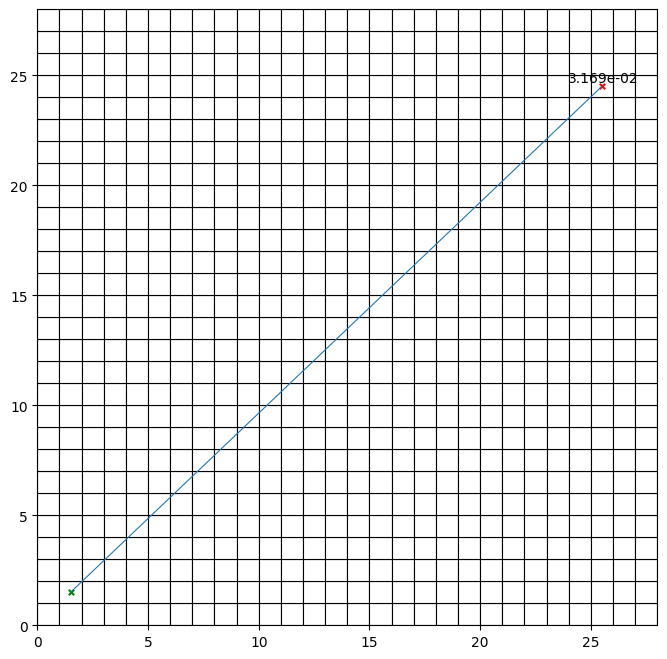

(None, None)

<Figure size 640x480 with 0 Axes>

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_grid, dr=dr, ax=ax)

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')

ax.set_xlim([0, HII_DIM])
ax.set_ylim([0, HII_DIM])
"""

for xx in r_cell[:,0]:
    for yy in r_cell[:,1]:
        plt.text(x=xx+0.05, y=yy+0.05, s='%.1e' %ncols[int(xx-0.5),int(yy-0.5)], ha='center', va='bottom')
plt.text(x=xx+0.05, y=yy+0.05, s='%.1e' %ncols[int(xx-0.5),int(yy-0.5)], ha='center', va='bottom')
"""
i_t, j_t = (r_target-0.5).astype(int)
plt.text(x=i_t+0.55, y=j_t+0.55, s='%.3e' %ncols[i_t, j_t], ha='center', va='bottom')

plt.savefig('rt_shortchar_grid.png', bbox_inches='tight')
plt.show(), plt.clf()

In [182]:
ncols[i_t, j_t]

0.03391064892046592